In [1]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================
import re
import html
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# SASTRAWI (INDONESIAN STEMMER)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.feature_extraction.text import TfidfVectorizer

from tqdm import tqdm

# =====================================================
# 3. STOPWORDS & STEMMER SETUP (SASTRAWI)
# =====================================================
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stop_words_id = set(stop_factory.get_stop_words())

protected_stopwords = {
    'tidak','tidakkah','tidaklah','tak','bukan','bukankah','bukanlah','bukannya','tanpa','belum','belumlah',
    'jangan','janganlah','jangankan','enggak','enggaknya','aku','akulah','saya','sayalah','kami','kamilah',
    'kita','kitalah','kamu','kamulah','anda','andalah','dia','dialah','ia','ialah','mereka','merekalah',
    'apa','apaan','apakah','apatah','bagaimana','bagaimanakah','berapa','berapakah','berapalah','bilakah',
    'kapan','kapankah','kenapa','mengapa','siapa','siapakah','siapapun','mana','bisakah','bolehkah',
    'bolehlah','perlukah','mungkinkah','haruskah','benarkah','sudahkah','tapi','tetapi','namun','melainkan',
    'padahal','walau','walaupun','meski','meskipun','sebaliknya','malah','malahan'
}

final_stopwords = stop_words_id - protected_stopwords


# =====================================================
# 4. PREPROCESSING & EMBEDDING FUNCTIONS
# =====================================================
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = html.unescape(text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    tokens = [t for t in tokens if t not in final_stopwords]
    tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)


# =====================================================
# 5. MODEL FACTORY (TANPA TRAINING)
# =====================================================
def build_stacking_model():
    base_learners = [
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svm', SVC(probability=True))
    ]

    meta_learner = LogisticRegression(max_iter=1000)

    return StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5
    )


In [ ]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

import json
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# =============================
# 1. LOAD DATASET HPT
# =============================
dataset_hpt_full = pd.read_csv("data_80.csv")
dataset_hpt_full = dataset_hpt_full[['Text', 'label']]
dataset_hpt_full = dataset_hpt_full.dropna(subset=['Text', 'label'])

# =============================
# 2. STRATIFIED SUBSET
# =============================
MAX_HPT_SAMPLES = 5000
RANDOM_STATE = 42

label_props = dataset_hpt_full['label'].value_counts(normalize=True)

subset_parts = []
for label, prop in label_props.items():
    n_samples = max(1, int(prop * MAX_HPT_SAMPLES))
    subset_parts.append(
        dataset_hpt_full[dataset_hpt_full['label'] == label]
        .sample(n=n_samples, random_state=RANDOM_STATE)
    )

dataset_hpt = (
    pd.concat(subset_parts)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

X_hpt_text = dataset_hpt['Text']
y_hpt = dataset_hpt['label']

# =============================
# 3. VECTORIZE
# =============================
tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=5000
)

X_hpt_clean = X_hpt_text.apply(preprocess_text)
X_hpt = tfidf.fit_transform(X_hpt_clean)

# =============================
# 4. STACKING MODEL
# =============================
base_learners = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE)),
    ('svm', SVC(probability=True))
]

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    n_jobs=-1
)

# =============================
# 5. PARAM GRID
# =============================
param_grid = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [None, 20, 40],
    'rf__min_samples_split': [2, 5],
    'svm__C': [0.1, 1, 10],
    'final_estimator__C': [0.1, 1, 10]
}

# =============================
# 6. GRID SEARCH (MULTI METRIC)
# =============================
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'auc': 'roc_auc',
    'log_loss': 'neg_log_loss'
}

grid_search = GridSearchCV(
    estimator=stacking_model,
    param_grid=param_grid,
    scoring=scoring,
    refit='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("🚀 Running Hyperparameter Tuning...")
grid_search.fit(X_hpt, y_hpt)

# =============================
# 7. AMBIL HASIL TERBAIK
# =============================
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_hpt)
y_prob = best_model.predict_proba(X_hpt)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_hpt, y_pred),
    "precision": precision_score(y_hpt, y_pred),
    "recall": recall_score(y_hpt, y_pred),
    "f1_score": f1_score(y_hpt, y_pred),
    "auc": roc_auc_score(y_hpt, y_prob)
}

print("\n✅ Evaluation Metrics (HPT Subset)")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

# =============================
# 8. SAVE KE JSON
# =============================
hpt_result = {
    "best_params": grid_search.best_params_,
    "cv_best_f1": grid_search.best_score_,
    "metrics_on_hpt_subset": metrics
}

with open("hyperparameters_ensemble_f1.json", "w") as f:
    json.dump(hpt_result, f, indent=4)

print("\n💾 Saved to hyperparameters_ensemble_f1.json")


🚀 Running Hyperparameter Tuning...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

✅ Evaluation Metrics (HPT Subset)
accuracy: 0.9824
precision: 0.9491
recall: 0.9591
f1_score: 0.9541
auc: 0.9975

💾 Saved to hyperparameters_ensemble_f1.json


In [2]:
# =====================================================
# 7. FINAL TRAINING (DIRECT 70 / 10 / 20)
# =====================================================

import json
import numpy as np
import pandas as pd
from scipy.sparse import vstack

# =============================
# LOAD DATA (SUDAH 70 / 10 / 20)
# =============================

train_df = pd.read_csv(r'C:\SKRIPSI BRYAN\Tahap 2\2B\EDA_70_100.csv')
val_df   = pd.read_csv(r'C:\SKRIPSI BRYAN\Tahap 2\2B\data_10_2B.csv')
test_df  = pd.read_csv(r'C:\SKRIPSI BRYAN\Tahap 2\2B\data_20_2B.csv')

X_train_text = train_df['Text']
y_train      = train_df['label']

X_val_text   = val_df['Text']
y_val        = val_df['label']

X_test_text  = test_df['Text']
y_test       = test_df['label']

# =============================
# TF-IDF VECTORIZATION
# =============================

tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=5000
)

# preprocess
X_train_clean = X_train_text.apply(preprocess_text)
X_val_clean   = X_val_text.apply(preprocess_text)
X_test_clean  = X_test_text.apply(preprocess_text)

# fit hanya di train (INI WAJIB BIAR GAK DATA LEAK)
X_train = tfidf.fit_transform(X_train_clean)

# transform sisanya
X_val  = tfidf.transform(X_val_clean)
X_test = tfidf.transform(X_test_clean)

# =============================
# LOAD BEST PARAMS
# =============================

with open(r"C:\SKRIPSI BRYAN\Tahap 1\hyperparameters_ensemble_f1.json", "r") as f:
    hpt_result = json.load(f)

BEST_PARAMS = hpt_result["best_params"]

final_model = build_stacking_model()
final_model.set_params(**BEST_PARAMS)

# =============================
# TRAIN FINAL MODEL
# =============================

# gabung train + val (karena udah gak butuh tuning lagi)
X_final = vstack([X_train, X_val])
y_final = np.concatenate([y_train, y_val])

print("🚀 Training final stacking model...")
final_model.fit(X_final, y_final)
print("✅ Training completed")

# =====================================================
# 8. FINAL EVALUATION
# =====================================================

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print('\n=== FINAL TEST EVALUATION ===')
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-score :', f1_score(y_test, y_pred))
print('AUC      :', roc_auc_score(y_test, y_proba))

🚀 Training final stacking model...
✅ Training completed

=== FINAL TEST EVALUATION ===
Accuracy : 0.9341491841491841
Precision: 0.8564231738035264
Recall   : 0.8585858585858586
F1-score : 0.8575031525851198
AUC      : 0.9659617003367004


=== CLASSIFICATION REPORT (PER LABEL) ===
              precision    recall  f1-score   support

     Label 0     0.9575    0.9568    0.9572      1320
     Label 1     0.8564    0.8586    0.8575       396

    accuracy                         0.9341      1716
   macro avg     0.9070    0.9077    0.9073      1716
weighted avg     0.9342    0.9341    0.9342      1716

=== CONFUSION MATRIX ===
[[1263   57]
 [  56  340]]


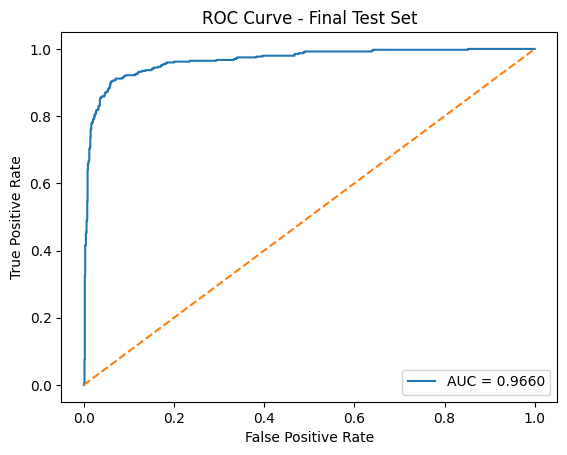

In [4]:
# =====================================================
# DETAILED EVALUATION: PER-CLASS + ROC CURVE
# =====================================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# =============================
# 1. PER-CLASS METRICS
# =============================
print("=== CLASSIFICATION REPORT (PER LABEL) ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Label 0", "Label 1"],
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

# =============================
# 2. ROC CURVE
# =============================
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Test Set")
plt.legend(loc="lower right")
plt.show()
